# Free Historical Options Research Notebook

This notebook is the daily EOD research path for free historical option-chain datasets.
It is source-agnostic, assumes a historical chain export with bid/ask and optionally IV/Greeks,
and keeps ex post explanation separate from ex ante forecasting.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data.fetch_free_history import (
    build_daily_research_candidates,
    evaluate_markowitz_sample,
    build_research_clean_panel,
    build_underlying_history,
    compute_ex_ante_moments,
    compute_ex_post_decomposition,
    diagnose_theta_units,
    load_raw_historical_chain,
    normalize_historical_chain,
    summarize_source_coverage,
)
from data.universes import get_named_universe

FREE_HISTORY_SOURCE = "optionsdx_csv"
FREE_HISTORY_INPUT = "/Users/hakeemshindy/cvx_options/data/raw/free_history"
FREE_HISTORY_PROCESSED_DIR = Path("/Users/hakeemshindy/cvx_options/data/processed/free_history")
USE_PROCESSED_CACHE = True
FORCE_REBUILD_NOTEBOOK_ARTIFACTS = False
FULL_TARGET_UNIVERSE = get_named_universe("liquid_research_plus_spy")
TARGET_UNIVERSE = ["SPY"]
MARKOWITZ_SYMBOLS = ["SPY"]
TARGET_DTE = 21
ROLL_DTE = 7
LOOKBACK_DAYS = 20
CV_TUNE_EVERY = 10
THETA_IS_PER_YEAR = True

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


In [2]:
normalized_cache = FREE_HISTORY_PROCESSED_DIR / f"normalized_{FREE_HISTORY_SOURCE}.parquet"

try:
    if USE_PROCESSED_CACHE and normalized_cache.exists():
        free_history_df = pd.read_parquet(normalized_cache)
        source_label = f"processed cache ({normalized_cache.name})"
    else:
        raw_free_history = load_raw_historical_chain(FREE_HISTORY_SOURCE, FREE_HISTORY_INPUT)
        free_history_df = normalize_historical_chain(raw_free_history, source=FREE_HISTORY_SOURCE)
        source_label = "raw files"
    free_history_df = free_history_df[free_history_df["symbol"].isin(TARGET_UNIVERSE)].reset_index(drop=True)
    print(
        f"Loaded {len(free_history_df):,} normalized rows across {free_history_df['symbol'].nunique()} symbols "
        f"from {source_label}."
    )
    display(free_history_df.head())
except FileNotFoundError as exc:
    free_history_df = pd.DataFrame()
    print(exc)
    print("Set FREE_HISTORY_INPUT to a local directory, file path, or glob for a free historical chain export.")


Loaded 1,944,324 normalized rows across 1 symbols from processed cache (normalized_optionsdx_csv.parquet).


,symbol,quote_time,quote_date,expiry,option_side,contract_symbol,strike,dte_calendar,underlying_spot,bid,ask,mid,last_price,volume,open_interest,implied_volatility,delta,gamma,theta,vega,rho,iv_source,greeks_source,price_source,data_source,row_quality_flag,ingested_at
0,SPY,2023-01-03 16:00:00,2023-01-03,2023-01-03,call,SPY_20230103_call_310.0000,310.0,0.0,380.82,70.86,71.01,70.935,73.66,0.0,0.0,4.34673,0.96551,0.00562,-0.10519,0.00913,0.00095,observed,observed,mid,optionsdx_csv,ok,2026-03-03 12:28:02.653176
1,SPY,2023-01-03 16:00:00,2023-01-03,2023-01-03,call,SPY_20230103_call_320.0000,320.0,0.0,380.82,60.86,61.01,60.935,60.24,2.0,0.0,3.87219,0.96015,0.00703,-0.10512,0.00997,0.00032,observed,observed,mid,optionsdx_csv,ok,2026-03-03 12:28:02.653176
2,SPY,2023-01-03 16:00:00,2023-01-03,2023-01-03,call,SPY_20230103_call_324.0000,324.0,0.0,380.82,56.86,57.01,56.935,0.00,0.0,0.0,3.68261,0.95788,0.00778,-0.10536,0.01014,0.00025,observed,observed,mid,optionsdx_csv,ok,2026-03-03 12:28:02.653176
3,SPY,2023-01-03 16:00:00,2023-01-03,2023-01-03,call,SPY_20230103_call_325.0000,325.0,0.0,380.82,55.32,56.48,55.900,0.00,0.0,0.0,3.59852,0.96337,0.00810,-0.06979,0.00901,0.00059,observed,observed,mid,optionsdx_csv,ok,2026-03-03 12:28:02.653176
4,SPY,2023-01-03 16:00:00,2023-01-03,2023-01-03,call,SPY_20230103_call_326.0000,326.0,0.0,380.82,54.34,55.54,54.940,0.00,0.0,0.0,3.59029,0.95600,0.00817,-0.10918,0.01064,0.00021,observed,observed,mid,optionsdx_csv,ok,2026-03-03 12:28:02.653176


## Data Source Audit

Coverage is measured against the configured target universe. Missing names are dropped rather than backfilled.


In [3]:
coverage = summarize_source_coverage(free_history_df, target_symbols=TARGET_UNIVERSE)
dropped_symbols = coverage.loc[~coverage["available"], "symbol"].tolist() if not coverage.empty else TARGET_UNIVERSE
print(f"Available symbols: {int(coverage['available'].sum())} / {len(TARGET_UNIVERSE)}")
print("Dropped symbols:", ", ".join(dropped_symbols[:15]) + (" ..." if len(dropped_symbols) > 15 else "") if dropped_symbols else "None")
display(coverage)


Available symbols: 1 / 1
Dropped symbols: None


,symbol,available,n_rows,n_dates,valid_bid_ask_share,mid_share,observed_iv_share,observed_greek_share,inferred_mid_share,inferred_last_share,latest_quote_date,latest_quote_time
0,SPY,True,1944324,250,0.913181,0.913181,0.916154,1.0,0.0,0.0,2023-12-29,2023-12-29 16:00:00


## Research-Clean Daily Panel

Each surviving symbol-date uses one expiry and exactly four contracts: ATM call, next OTM call, ATM put, next OTM put.


In [4]:
candidates_cache = FREE_HISTORY_PROCESSED_DIR / f"research_candidates_{FREE_HISTORY_SOURCE}.parquet"
panel_cache = FREE_HISTORY_PROCESSED_DIR / f"research_panel_{FREE_HISTORY_SOURCE}.parquet"

if USE_PROCESSED_CACHE and not FORCE_REBUILD_NOTEBOOK_ARTIFACTS and candidates_cache.exists() and panel_cache.exists():
    research_candidates = pd.read_parquet(candidates_cache)
    research_panel = pd.read_parquet(panel_cache)
    research_candidates = research_candidates[research_candidates["symbol"].isin(TARGET_UNIVERSE)].reset_index(drop=True)
    research_panel = research_panel[research_panel["symbol"].isin(TARGET_UNIVERSE)].reset_index(drop=True)
    print(f"Loaded research candidates and panel from processed cache in {FREE_HISTORY_PROCESSED_DIR}.")
else:
    research_candidates = build_daily_research_candidates(free_history_df, target_dte=TARGET_DTE, roll_dte=ROLL_DTE)
    research_panel = build_research_clean_panel(free_history_df, target_dte=TARGET_DTE, roll_dte=ROLL_DTE)
print(f"Candidate rows: {len(research_candidates)}")
print("Candidate build failure counts:", research_candidates.attrs.get("failure_counts", {}))
print(f"Matched next-day research rows: {len(research_panel)}")
print("Panel build failure counts:", research_panel.attrs.get("failure_counts", {}))
if not research_candidates.empty:
    preview_cols = [
        "symbol", "quote_date", "chosen_expiry", "chosen_dte", "chosen_expiry_2", "chosen_dte_2",
        "call_1_symbol", "call_1_strike", "call_2_symbol", "call_2_strike",
        "put_1_symbol", "put_1_strike", "put_2_symbol", "put_2_strike",
    ]
    display(research_candidates[preview_cols].head())
if not research_panel.empty:
    panel_cols = [
        "symbol", "date_t", "date_t1", "spot_t", "spot_t1", "R_und_real",
        "call_1_symbol", "call_1_mid_t", "call_1_mid_t1", "call_1_R_real",
        "put_1_symbol", "put_1_mid_t", "put_1_mid_t1", "put_1_R_real",
    ]
    display(research_panel[panel_cols].head())


Loaded research candidates and panel from processed cache in /Users/hakeemshindy/cvx_options/data/processed/free_history.
Candidate rows: 250
Candidate build failure counts: {'no_valid_expiry': 0, 'no_call_wing': 2, 'no_put_wing': 0, 'roll_missing_data': 20, 'roll_dte_trigger': 55}
Matched next-day research rows: 247
Panel build failure counts: {'no_valid_expiry': 0, 'no_call_wing': 2, 'no_put_wing': 0, 'roll_missing_data': 20, 'roll_dte_trigger': 55, 'no_next_trading_day': 4, 'missing_contract_t1': 0, 'invalid_mid_t1': 3}


KeyError: "['chosen_expiry_2', 'chosen_dte_2'] not in index"

## Theta Unit Diagnostic

This compares daily vs annualized theta conventions on the ex post decomposition and updates `THETA_IS_PER_YEAR` using the recommended convention.


In [5]:
if research_panel.empty:
    print(f"No matched research panel rows are available; keeping THETA_IS_PER_YEAR={THETA_IS_PER_YEAR}.")
else:
    theta_diagnosis = diagnose_theta_units(research_panel)
    theta_overall = pd.DataFrame(
        [
            {"theta_units": "per_year", **theta_diagnosis["per_year"]["overall"]},
            {"theta_units": "per_day", **theta_diagnosis["per_day"]["overall"]},
        ]
    )
    print(f"Theta unit recommendation: {theta_diagnosis['recommendation']}")
    display(theta_overall)
    print("\nPer-bucket stats (theta interpreted per year):")
    display(theta_diagnosis["per_year"]["by_bucket"])
    print("\nPer-bucket stats (theta interpreted per day):")
    display(theta_diagnosis["per_day"]["by_bucket"])
    THETA_IS_PER_YEAR = theta_diagnosis["recommendation"] == "per_year"
    print(f"THETA_IS_PER_YEAR set to {THETA_IS_PER_YEAR}")


Theta unit recommendation: per_day


,theta_units,n_obs,corr,slope,intercept,mae,rmse
0,per_year,988,0.960580,0.944615,-0.062116,0.078278,0.122576
1,per_day,988,0.971397,0.940977,-0.017493,0.057624,0.091720



Per-bucket stats (theta interpreted per year):


,bucket,n_obs,corr,slope,intercept,mae,rmse
0,call_1,247,0.965168,0.934389,-0.055225,0.071869,0.113501
1,call_2,247,0.961094,0.924220,-0.060351,0.078740,0.126672
2,put_1,247,0.959580,0.964377,-0.062966,0.078590,0.120830
3,put_2,247,0.955796,0.955518,-0.067611,0.083913,0.128731



Per-bucket stats (theta interpreted per day):


,bucket,n_obs,corr,slope,intercept,mae,rmse
0,call_1,247,0.979473,0.948097,-0.018966,0.049100,0.077131
1,call_2,247,0.976362,0.941643,-0.021368,0.054191,0.087427
2,put_1,247,0.966097,0.943795,-0.014533,0.061269,0.096799
3,put_2,247,0.962672,0.933931,-0.015605,0.065934,0.103379


THETA_IS_PER_YEAR set to False


## Ex Post Taylor Decomposition

This section explains realized next-day moves using time-t Greeks plus realized dS and realized dIV. These are ex post explanations, not forecasts.


,bucket,mean_explained,mean_real,mae,rmse,corr
0,call_1,0.036727,0.015855,0.049100,0.077131,0.979473
1,call_2,0.041222,0.017448,0.054191,0.087427,0.976362
2,put_1,-0.045821,-0.057779,0.061269,0.096799,0.966097
3,put_2,-0.048369,-0.060779,0.065934,0.103379,0.962672


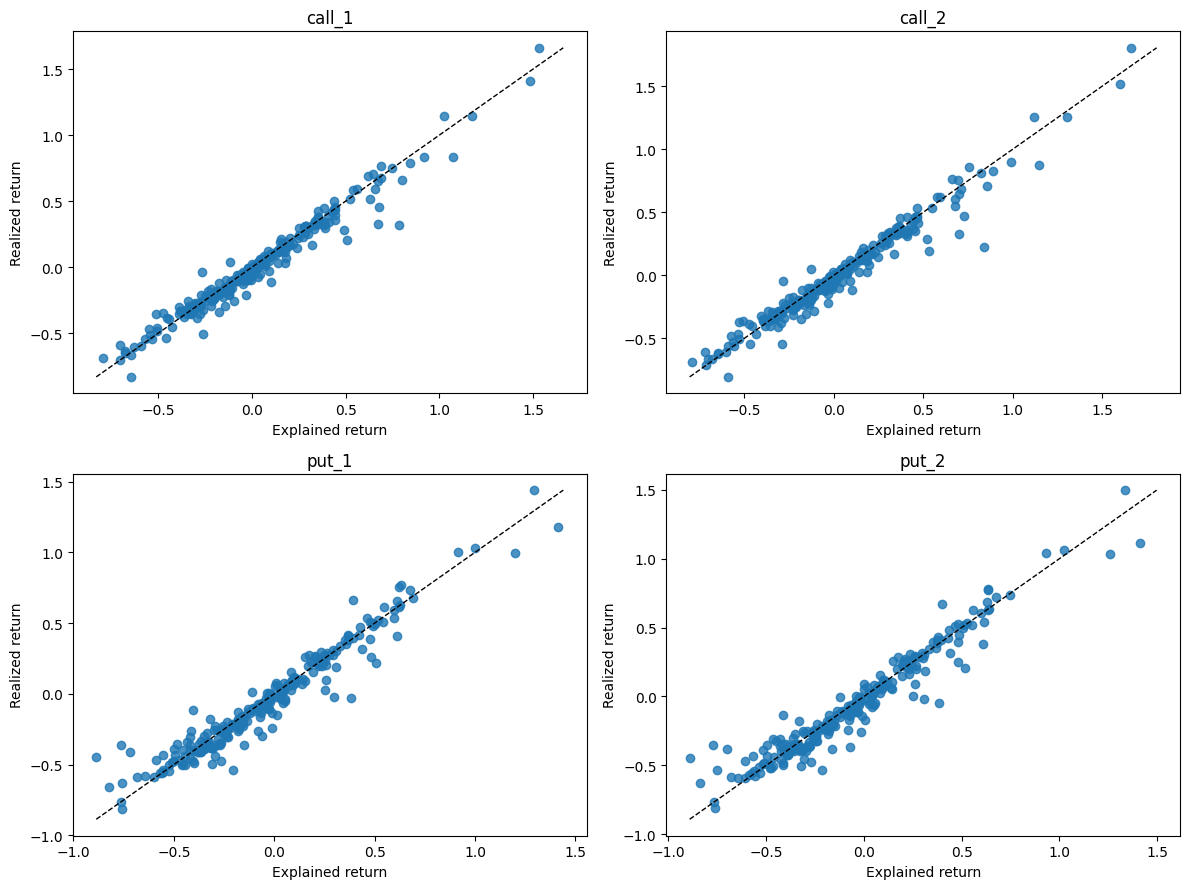

In [6]:
ex_post = compute_ex_post_decomposition(research_panel, theta_is_per_year=THETA_IS_PER_YEAR)
if ex_post.empty:
    print("No matched research-clean rows are available for ex post validation yet.")
else:
    ex_post_summary = (
        ex_post.groupby("bucket", as_index=False)
        .agg(
            mean_explained=("R_explained", "mean"),
            mean_real=("R_real", "mean"),
            mae=("abs_error", "mean"),
            rmse=("abs_error", lambda s: float(np.sqrt(np.mean(np.square(s))))),
            corr=("R_real", lambda s: float(ex_post.loc[s.index, ["R_explained", "R_real"]].corr().iloc[0, 1]) if len(s) > 1 else np.nan),
        )
    )
    display(ex_post_summary)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
    for ax, bucket in zip(axes.flat, ["call_1", "call_2", "put_1", "put_2"]):
        sub = ex_post[ex_post["bucket"] == bucket]
        ax.scatter(sub["R_explained"], sub["R_real"], alpha=0.8)
        if not sub.empty:
            lims = [min(sub["R_explained"].min(), sub["R_real"].min()), max(sub["R_explained"].max(), sub["R_real"].max())]
            ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
        ax.set_title(bucket)
        ax.set_xlabel("Explained return")
        ax.set_ylabel("Realized return")
    plt.tight_layout()
    plt.show()


## Full-Sample Covariance Check and Markowitz Path

This section first builds the ex ante moments from the matched daily panel, then fixes a common risky universe over the full common sample, compares the structural covariance estimate and robust optimizer risk matrix to realized covariance, and solves a long-only Markowitz allocation at each trading-day rebalance.


Experiment setup:
- Fixed symbol universe: SPY
- Risky assets: 5 = 1 underlyings + 4 options
- Trading-day periods used: 226 from 2023-02-02 to 2023-12-28
- Rebalance cadence: daily only (initial weights on day 0, then one rebalance per trading day)
- Rebalances executed after initial day: 225
- Portfolio is long-only and fully invested across risky assets only (no cash sleeve, no Black-Litterman)
- Stable bucket ids are maintained with contract rolls when DTE < 7 or data is missing
- Means are predicted from lagged underlying moments plus time-t delta-gamma-theta (no ex-ante vega drift)
- Parameters are re-tuned every 10 rebalance dates using rolling cross-validation on the previous lookback window (80% train / 20% validation), then reused in between
- Reduced CV grid size: 16 combinations (2 lambda x 2 xi x 2 kappa x 2 eps)
- Actual CV re-tunes executed: 22
- Mean selected lambda=3.124, xi=0.672, kappa=0.225, eps_wc=0.017
- Option-mu rolling calibration mean scale: -0.121 (scale is s

,SPY_UND,SPY_CALL_1,SPY_CALL_2,SPY_PUT_1,SPY_PUT_2
SPY_UND,0.000068,0.002732,0.002867,-0.003108,-0.003169
SPY_CALL_1,0.002732,0.140429,0.141708,-0.123914,-0.126920
SPY_CALL_2,0.002867,0.141708,0.155469,-0.130651,-0.133827
SPY_PUT_1,-0.003108,-0.123914,-0.130651,0.179959,0.173972
SPY_PUT_2,-0.003169,-0.126920,-0.133827,0.173972,0.187530



Average empirical diagonal option noise floor over the common sample:


,SPY_UND,SPY_CALL_1,SPY_CALL_2,SPY_PUT_1,SPY_PUT_2
SPY_UND,0.0,0.000000,0.000000,0.000000,0.000000
SPY_CALL_1,0.0,0.005507,0.000000,0.000000,0.000000
SPY_CALL_2,0.0,0.000000,0.006566,0.000000,0.000000
SPY_PUT_1,0.0,0.000000,0.000000,0.009307,0.000000
SPY_PUT_2,0.0,0.000000,0.000000,0.000000,0.010093



Average robust optimizer risk matrix over the common sample (A_eff):


...


Selected CV parameters (tail):


,risk_aversion,turnover_penalty,kappa_robust,eps_wc,cv_sharpe,cv_train_n,cv_val_n,cv_ran,cv_anchor_date,cv_grid_size
2023-12-21,1.0,0.3,0.15,0.05,4.803834,16,4,False,2023-12-20,16
2023-12-22,1.0,0.3,0.15,0.05,4.803834,16,4,False,2023-12-20,16
2023-12-26,1.0,0.3,0.15,0.05,4.803834,16,4,False,2023-12-20,16
2023-12-27,1.0,0.3,0.15,0.05,4.803834,16,4,False,2023-12-20,16
2023-12-28,1.0,0.3,0.15,0.05,4.803834,16,4,False,2023-12-20,16



Zero-risk diagnostics (tail):


,base_rank,structural_rank,effective_rank,n_assets,base_min_eig,structural_min_eig,effective_min_eig,effective_max_eig,effective_condition_number,ridge_added,zero_risk_fixed,date_t
221,1,3,5,5,-1.191288e-17,-1.252971e-20,0.000007,629.410862,9.211014e+07,1.000000e-10,True,2023-12-21
222,1,3,5,5,-4.060631e-17,-7.994711e-21,0.000008,720.212901,9.550456e+07,1.000000e-10,True,2023-12-22
223,1,3,5,5,-6.083254e-17,-3.573719e-17,0.000008,1071.619931,1.426238e+08,1.000000e-10,True,2023-12-26
224,1,3,5,5,-2.030295e-17,-3.141566e-17,0.000007,1405.141023,1.897526e+08,1.000000e-10,True,2023-12-27
225,1,3,5,5,-1.046024e-16,-6.042102e-21,0.000007,1666.411773,2.261099e+08,1.000000e-10,True,2023-12-28



Portfolio-level return diagnostics:
- mean predicted=0.043% | mean realized=-0.066% | corr(pred, real)=-0.110


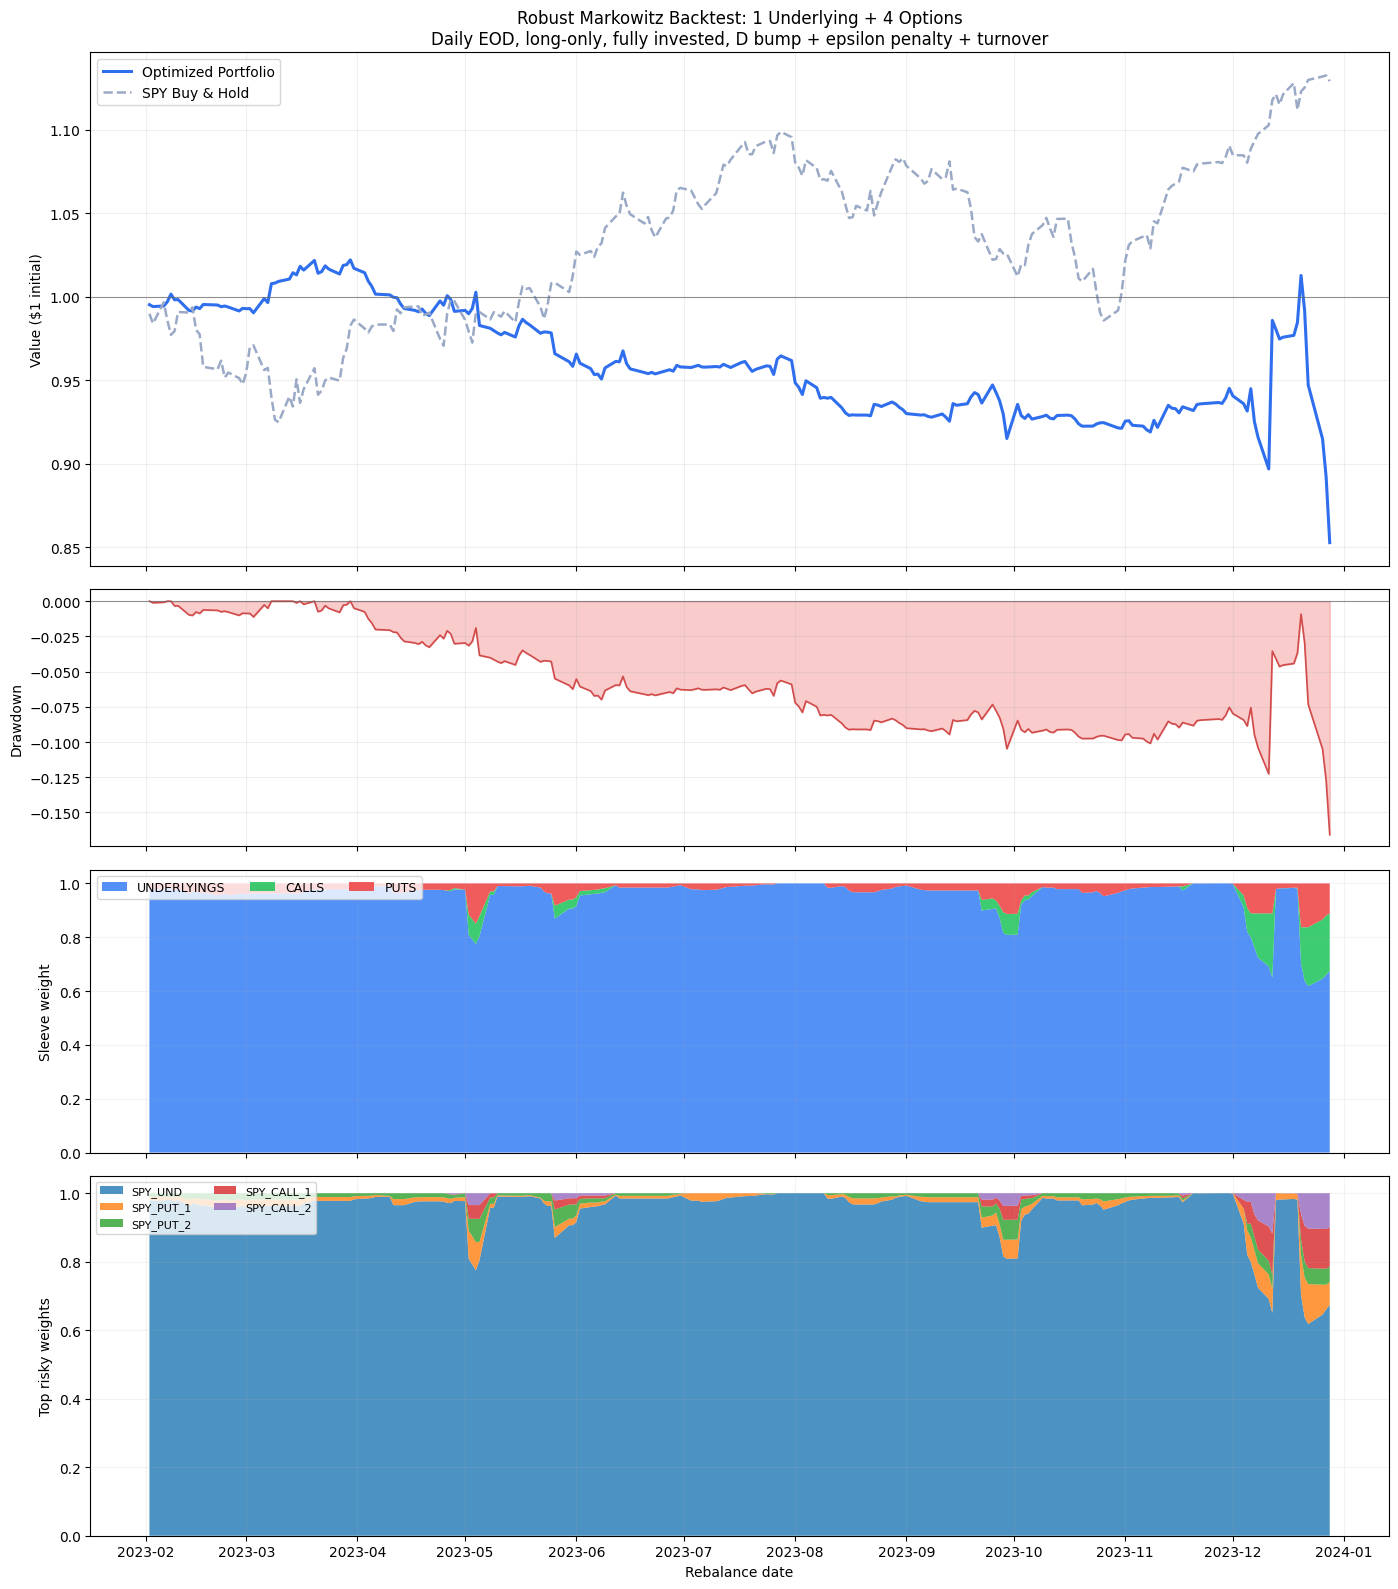

,mean_pred,mean_real,bias,mae,corr_pred_real
SPY_UND,0.000410,0.000570,-0.000160,0.006343,-0.019970
SPY_CALL_1,0.000291,0.006956,-0.006664,0.267393,0.006679
SPY_CALL_2,0.000163,0.008340,-0.008177,0.280189,0.002283
SPY_PUT_1,0.000845,-0.049182,0.050027,0.288689,-0.158258
SPY_PUT_2,0.000504,-0.052005,0.052508,0.293435,-0.140181


In [8]:
underlying_history = build_underlying_history(free_history_df)
ex_ante = compute_ex_ante_moments(
    research_panel,
    underlying_history,
    lookback=LOOKBACK_DAYS,
    theta_is_per_year=THETA_IS_PER_YEAR,
) if not research_panel.empty else pd.DataFrame()

if ex_ante.empty:
    print("Run the ex ante section first; there are no moments to evaluate yet.")
else:
    markowitz_eval = evaluate_markowitz_sample(
        ex_ante,
        underlying_history,
        symbols=MARKOWITZ_SYMBOLS,
        lookback=LOOKBACK_DAYS,
        daily_only=True,
        risk_aversion=5.0,
        turnover_penalty=1.0,
        eps_wc=0.05,
        kappa_robust=0.25,
        cv_reopt_every=CV_TUNE_EVERY,
    )
    if not markowitz_eval:
        print("No common multi-asset sample is available for covariance validation and Markowitz yet.")
    else:
        print(markowitz_eval["summary"])
        print("\nAverage structural predicted risky covariance over the common sample (V Sigma V^T + empirical diagonal noise):")
        display(markowitz_eval["structural_cov_mean"])
        print("\nAverage empirical diagonal option noise floor over the common sample:")
        if "empirical_noise_mean" in markowitz_eval:
            display(markowitz_eval["empirical_noise_mean"])
        else:
            print("empirical_noise_mean is unavailable in the current in-memory result; rerun this cell after the import cell refreshes the module.")
        print("\nAverage robust optimizer risk matrix over the common sample (A_eff):")
        display(markowitz_eval["optimizer_cov_mean"])
        print("\nAverage robust add-on over the common sample (D + eps_wc * V V^T):")
        display(markowitz_eval["robust_addon_mean"])
        print("\nRealized risky covariance over the same sample:")
        display(markowitz_eval["realized_cov"])
        print("\nStructural covariance gap (structural estimate - realized):")
        display(markowitz_eval["cov_gap"])
        print("\nOptimizer risk gap (A_eff - realized):")
        display(markowitz_eval["optimizer_cov_gap"])
        print("\nLatest optimal allocation:")
        display(markowitz_eval["latest_allocation"].to_frame("weight"))
        print("\nSelected CV parameters (tail):")
        display(markowitz_eval["param_by_date"].tail())
        print("\nZero-risk diagnostics (tail):")
        display(markowitz_eval["risk_diagnostics"].tail())
        portfolio_path = markowitz_eval["portfolio_path"].copy()
        weight_plot = markowitz_eval["weight_path"].copy()
        sleeve_plot = markowitz_eval["aggregate_weight_path"].copy()
        avg_weights = weight_plot.mean().sort_values(ascending=False)
        top_assets = avg_weights.head(min(8, len(avg_weights))).index.tolist()
        top_plot = weight_plot[top_assets]
        portfolio_mean_pred = float(portfolio_path["predicted_portfolio_return"].mean())
        portfolio_mean_real = float(portfolio_path["realized_portfolio_return"].mean())
        portfolio_corr = float(portfolio_path[["predicted_portfolio_return", "realized_portfolio_return"]].corr().iloc[0, 1])
        print("\nPortfolio-level return diagnostics:")
        print(
            f"- mean predicted={portfolio_mean_pred:.3%} | mean realized={portfolio_mean_real:.3%} | "
            f"corr(pred, real)={portfolio_corr:.3f}"
        )
        fig, axes = plt.subplots(
            4,
            1,
            figsize=(14, 16),
            sharex=True,
            gridspec_kw={"height_ratios": [2.0, 1.0, 1.1, 1.4]},
        )
        ax_value, ax_drawdown, ax_sleeves, ax_alloc = axes
        ax_value.plot(
            portfolio_path["date_t"],
            portfolio_path["portfolio_value"],
            label="Optimized Portfolio",
            color="#2f6fed",
            linewidth=2.2,
        )
        ax_value.plot(
            portfolio_path["date_t"],
            portfolio_path["benchmark_value"],
            label=markowitz_eval["benchmark_label"],
            color="#9aa9c6",
            linewidth=1.8,
            linestyle="--",
        )
        ax_value.axhline(1.0, color="#666666", linewidth=0.8, alpha=0.7)
        ax_value.set_ylabel("Value ($1 initial)")
        ax_value.set_title(
            f"Robust Markowitz Backtest: {len(markowitz_eval['symbols'])} Underlying + {4 * len(markowitz_eval['symbols'])} Options\n"
            "Daily EOD, long-only, fully invested, D bump + epsilon penalty + turnover"
        )
        ax_value.legend(loc="upper left")
        ax_value.grid(alpha=0.2)
        ax_drawdown.fill_between(
            portfolio_path["date_t"],
            portfolio_path["drawdown"],
            0.0,
            color="#ef6a6a",
            alpha=0.35,
        )
        ax_drawdown.plot(portfolio_path["date_t"], portfolio_path["drawdown"], color="#d14b4b", linewidth=1.2)
        ax_drawdown.axhline(0.0, color="#666666", linewidth=0.8, alpha=0.7)
        ax_drawdown.set_ylabel("Drawdown")
        ax_drawdown.grid(alpha=0.2)
        ax_sleeves.stackplot(
            sleeve_plot.index,
            sleeve_plot["UNDERLYINGS"],
            sleeve_plot["CALLS"],
            sleeve_plot["PUTS"],
            labels=["UNDERLYINGS", "CALLS", "PUTS"],
            alpha=0.88,
            colors=["#3b82f6", "#22c55e", "#ef4444"],
        )
        ax_sleeves.set_ylabel("Sleeve weight")
        ax_sleeves.legend(loc="upper left", ncol=4, fontsize=9)
        ax_sleeves.grid(alpha=0.15)
        ax_alloc.stackplot(
            top_plot.index,
            *[top_plot[col] for col in top_plot.columns],
            labels=top_plot.columns.tolist(),
            alpha=0.8,
        )
        ax_alloc.set_ylabel("Top risky weights")
        ax_alloc.set_xlabel("Rebalance date")
        ax_alloc.legend(loc="upper left", ncol=2, fontsize=8)
        ax_alloc.grid(alpha=0.15)
        plt.tight_layout()
        plt.show()

        display(markowitz_eval["mu_diagnostics"])
